In [1]:
!pip install seaborn


# 🚇 Delhi Metro Data Analysis Project
This project analyzes Delhi Metro travel data to understand passenger trends, station usage, ticket types, and profit patterns using Python, Pandas, and data visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## 📂 Data Loading

In this step, we import the required libraries and load the raw dataset into a pandas DataFrame for analysis.


In [3]:
df = pd.read_csv("delhi_metro_raw.csv")
df.head()


,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


## 🔍 Data Understanding

Here, we explore the structure of the dataset, including the number of rows and columns, data types, summary statistics, and missing values.
This helps us understand the quality and characteristics of the data before cleaning.


In [4]:
df.shape


(150000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  object 
 2   From_Station        150000 non-null  object 
 3   To_Station          150000 non-null  object 
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  object 
 9   Remarks             123743 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 11.4+ MB


In [6]:
df.columns

Index(['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare',
       'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks'],
      dtype='object')

## 🧹 Data Cleaning

In this step, we clean the dataset to improve data quality.  
This includes handling missing values, removing extra spaces from station names, standardizing text formatting, and fixing inconsistent entries.
Data cleaning ensures accurate and meaningful analysis.


🔹 1️⃣ Convert Date Column to Proper Format

In [7]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



🔹 2️⃣ Check Missing Values

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]


Passengers      1500
Ticket_Type     1500
Remarks        26257
dtype: int64

🔹 3️⃣ Fill Missing Ticket Type with Mode

In [9]:
max_ticket_type = df['Ticket_Type'].mode()[0]
df['Ticket_Type'] = df['Ticket_Type'].fillna(max_ticket_type)


🔹 4️⃣ Fill Missing Passengers with Median

In [10]:
median_pass = int(df['Passengers'].median(skipna=True))
df['Passengers'] = df['Passengers'].fillna(median_pass)

🔹 5️⃣ Handling Missing Values in Remarks

In [11]:
df['Remarks'] = df['Remarks'].replace('', np.nan)


By Using Mode

In [12]:
max_remarks_value = df['Remarks'].mode()[0]
df['Remarks'] = df['Remarks'].fillna(max_remarks_value)


In [13]:
df['Remarks'].value_counts(dropna=False)


Remarks
off-peak       51116
festival       24812
maintenance    24771
weekend        24710
peak           24591
Name: count, dtype: int64

🔹 6️⃣ Remove Extra Spaces in Station Names

In [14]:
df['From_Station'] = df['From_Station'].astype(str).str.strip().str.title()
df['To_Station'] = df['To_Station'].astype(str).str.strip().str.title()


🔹 7️⃣ Final Missing Values Check

In [15]:
df.isnull().sum()


TripID                0
Date                  0
From_Station          0
To_Station            0
Distance_km           0
Fare                  0
Cost_per_passenger    0
Passengers            0
Ticket_Type           0
Remarks               0
dtype: int64

🧹 Trailing Spaces Cleaning in "From_Station"

In [16]:
print(df['From_Station'].sample(5))


24220     Kalkaji Mandir
41238          Hauz Khas
120512     Chandni Chowk
61884        Kirti Nagar
91989        Laxmi Nagar
Name: From_Station, dtype: object


## 📈 Data Visualization
In this section, we visualize important insights such as busiest stations, fare patterns, passenger distribution, and ticket type usage.


🔹 1️⃣ Top 10 Boarding Stations

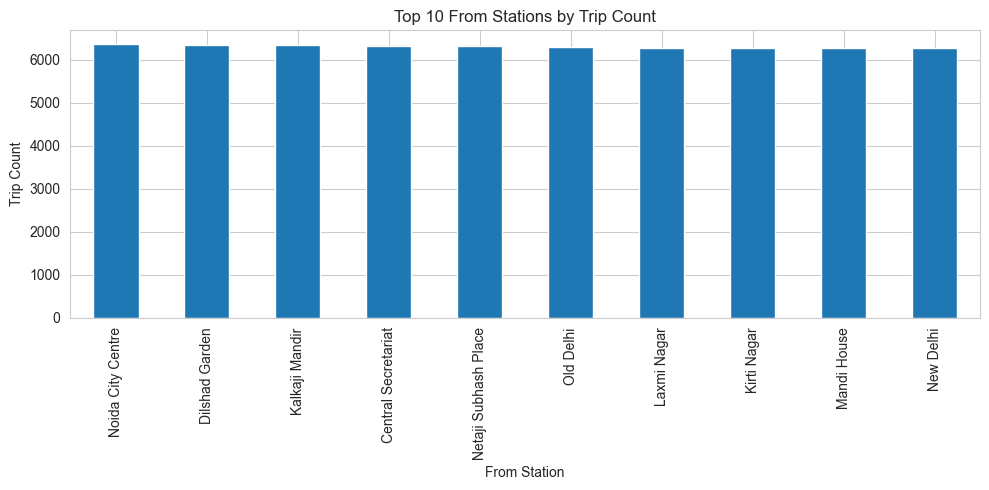

In [17]:
plt.figure(figsize=(10,5))
station_counts = df['From_Station'].value_counts().nlargest(10)
station_counts.plot(kind='bar')
plt.title('Top 10 From Stations by Trip Count')
plt.xlabel('From Station')
plt.ylabel('Trip Count')
plt.tight_layout()
plt.show()


🔹 2️⃣ Top Busiest Stations (From + To)

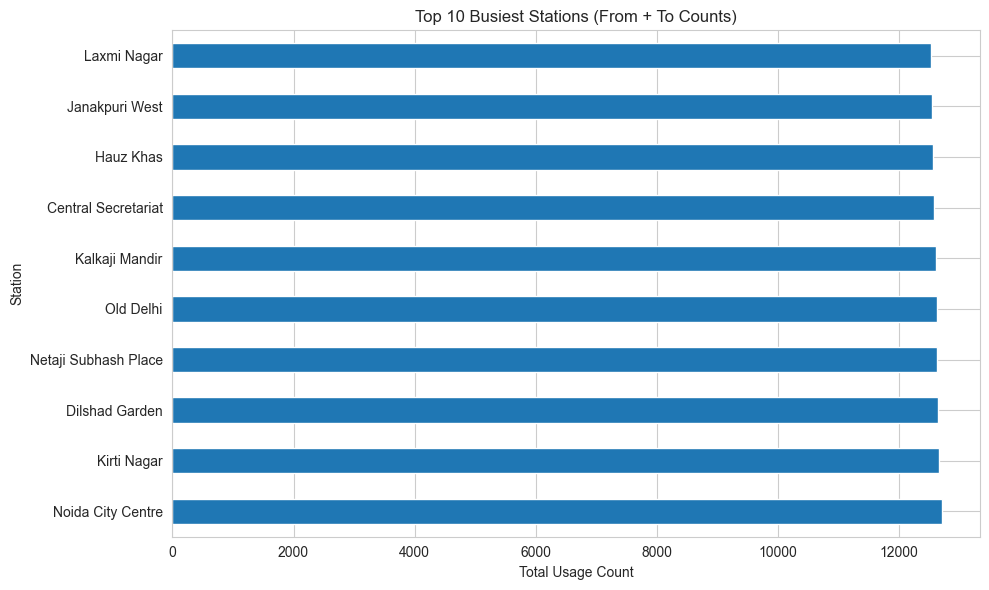

In [18]:
plt.figure(figsize=(10,6))
total_station_counts = (df['From_Station'].value_counts() + df['To_Station'].value_counts()).nlargest(10)
total_station_counts.plot(kind='barh')
plt.title('Top 10 Busiest Stations (From + To Counts)')
plt.xlabel('Total Usage Count')
plt.ylabel('Station')
plt.tight_layout()
plt.show()


🔹 3️⃣ Percentage Contribution of Top Stations

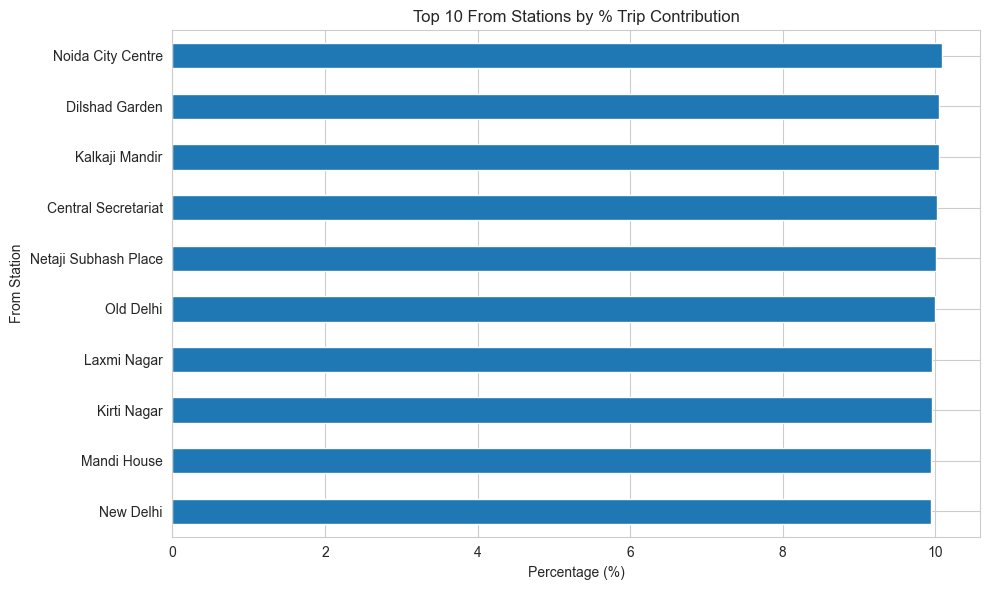

In [19]:
plt.figure(figsize=(10,6))
station_counts = df['From_Station'].value_counts().nlargest(10)
station_pct = (station_counts / station_counts.sum()) * 100

station_pct.plot(kind='barh')
plt.title('Top 10 From Stations by % Trip Contribution')
plt.xlabel('Percentage (%)')
plt.ylabel('From Station')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


🔹 4️⃣ Fare Distribution

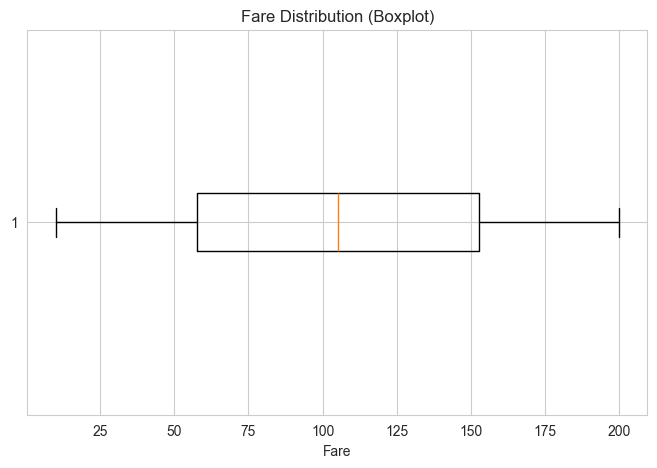

In [20]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Fare'].dropna(), vert=False)
plt.title('Fare Distribution (Boxplot)')
plt.xlabel('Fare')
plt.show()


🔹 5️⃣ Distance vs Fare Relationship

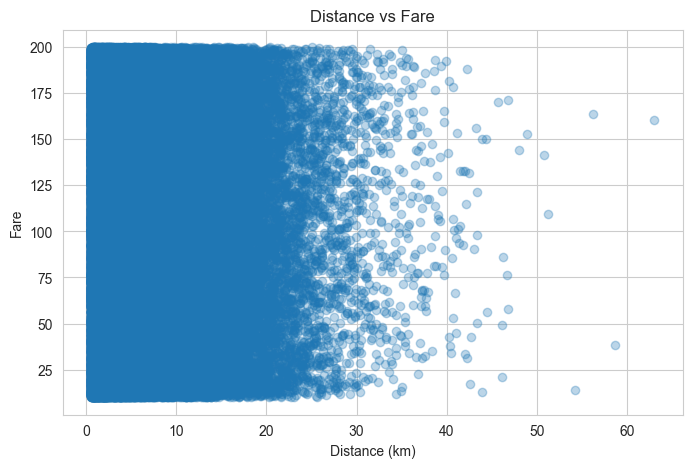

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['Distance_km'], df['Fare'], alpha=0.3)
plt.title('Distance vs Fare')
plt.xlabel('Distance (km)')
plt.ylabel('Fare')
plt.show()


🔹 6️⃣ Ticket Type Share

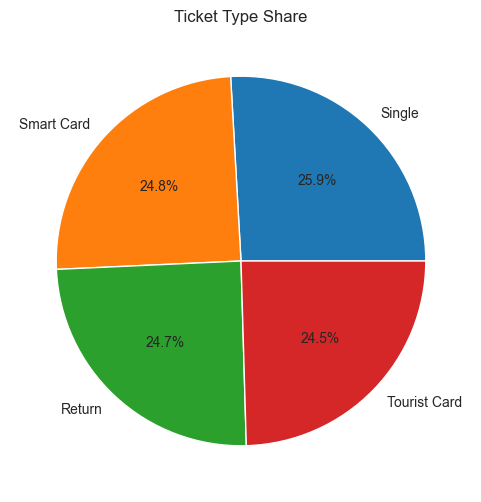

In [22]:
plt.figure(figsize=(6,6))
tt = df['Ticket_Type'].value_counts()
plt.pie(tt, labels=tt.index, autopct='%1.1f%%')
plt.title('Ticket Type Share')
plt.show()


🔹 7️⃣ Passenger Distribution

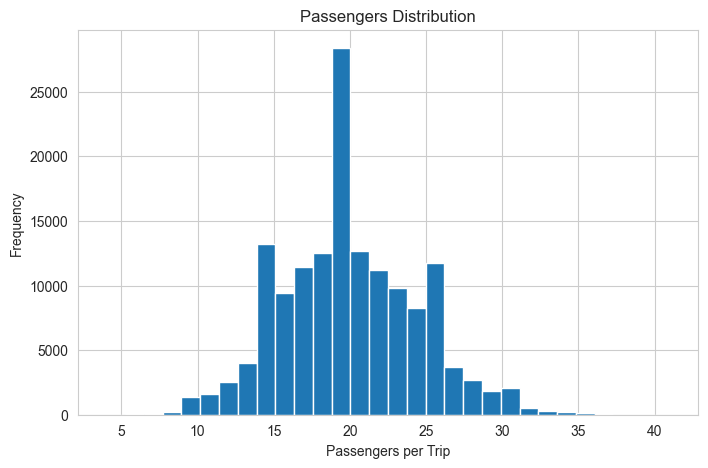

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['Passengers'], bins=30)
plt.title('Passengers Distribution')
plt.xlabel('Passengers per Trip')
plt.ylabel('Frequency')
plt.show()


🔹 8️⃣ Daily Profit Trend

In [24]:
df['Profit'] = df['Fare'] * df['Passengers']


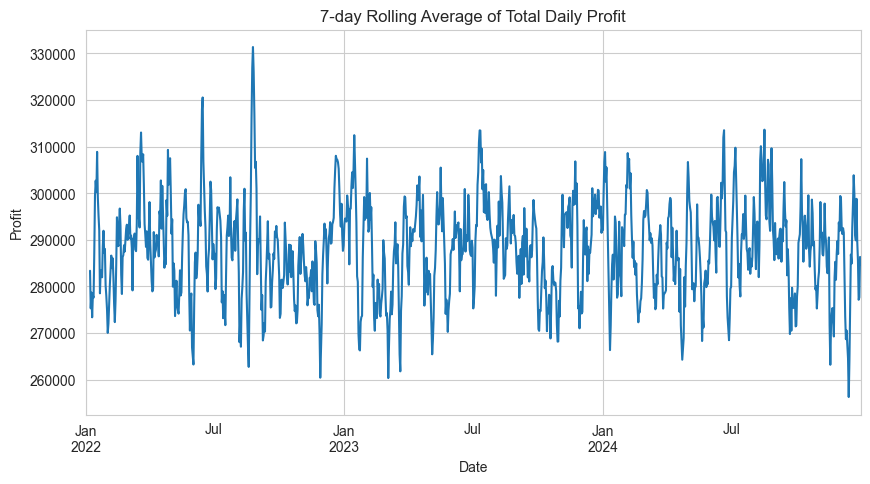

In [25]:
plt.figure(figsize=(10,5))
daily = df.groupby('Date')['Profit'].sum().sort_index()
daily.rolling(window=7).mean().plot()
plt.title('7-day Rolling Average of Total Daily Profit')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.show()
